# Spring of Code - Artificial Intelligence
## Week 06: Advanced Machine Learning Models

### Day 03: Support Vector Machines and Decision Trees

In this notebook, we will explore **Support Vector Machines (SVM)** and **Decision Trees** using Python's Scikit-Learn library.


# Support Vector Machines (SVM)
A powerful machine learning algorithm used for classification and regression tasks.


In [1]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
type(iris)

sklearn.utils._bunch.Bunch

In [2]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [41]:
X = iris.data.values
y = iris.target.values
print(f"Features' shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features' shape: (150, 4)
Target shape: (150,)


In [4]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [42]:
X = X[:100]
y = y[:100]
print(f"Features' shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features' shape: (100, 4)
Target shape: (100,)


In [8]:
iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


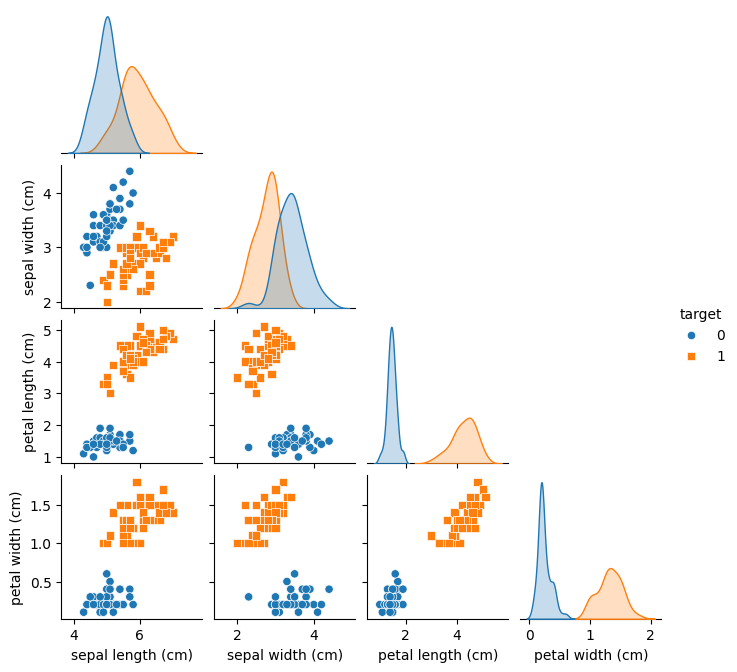

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    iris.frame.iloc[:100], hue="target", markers=["o", "s"], corner=True, height=1.7
)
plt.show()

## Linear SVM Classification
In linear SVM, the goal is to find the optimal hyperplane that separates different classes in the feature space. The hyperplane is chosen to maximize the margin between the classes.

<img src="linear_svm.png" alt="Linear SVM" width="800">

### Soft Margin Classification
In real-world scenarios, data is often not perfectly separable. Soft margin SVM allows some misclassifications by introducing slack variables. The objective is to find a balance between maximizing the margin and minimizing classification errors.

<img src="soft_margin_classification.png" alt="Soft Margin SVM" width="800">

In [43]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1)
model.fit(X, y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [44]:
model.score(X, y)

1.0

In [45]:
X.shape

(100, 4)

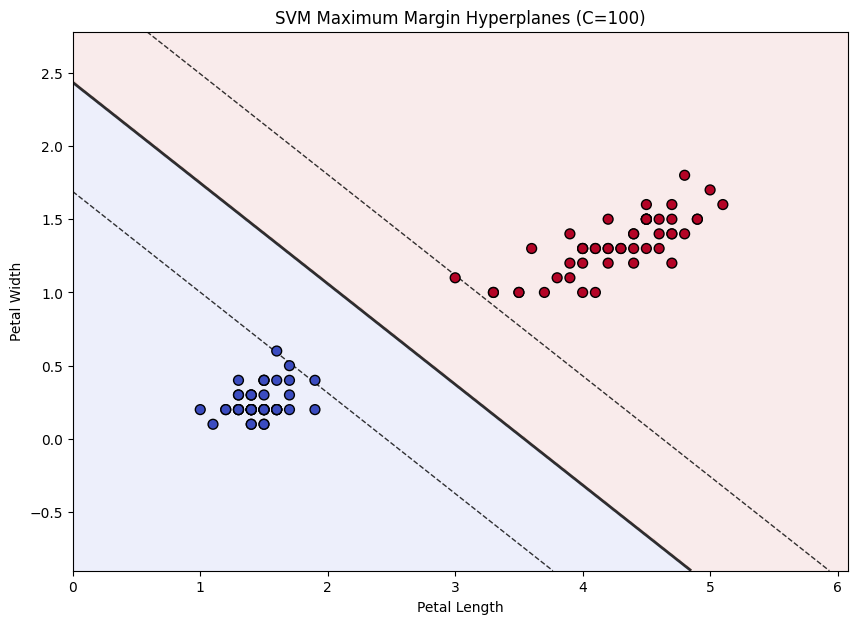

In [52]:
# Use only petal length & petal width for 2D visualization
X_2d = X[:, 2:4]

model_2d = LinearSVC(C=100)
model_2d.fit(X_2d, y)

# Visualize the decision boundary
import numpy as np
def plot_decision_boundary(model, X, y):
    # 1. Setup Grid
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Get predictions and distances
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z_pred = model.predict(grid_points).reshape(xx.shape)
    Z_dist = model.decision_function(grid_points)

    plt.figure(figsize=(10, 7))

    # 3. Plot Regions (Very light alpha)
    plt.contourf(xx, yy, Z_pred, alpha=0.1, cmap='coolwarm')

    # 4. Draw the Hyperplanes AND Margins
    # Levels [-1, 0, 1] represent the margins and the central hyperplane
    if Z_dist.ndim == 1:
        # BINARY CASE
        zz = Z_dist.reshape(xx.shape)
        plt.contour(xx, yy, zz, levels=[-1, 0, 1], colors='k', 
                    linestyles=['--', '-', '--'], alpha=0.8, linewidths=[1, 2, 1])
    else:
        # MULTICLASS CASE (One-vs-Rest)
        for i in range(Z_dist.shape[1]):
            zz = Z_dist[:, i].reshape(xx.shape)
            plt.contour(xx, yy, zz, levels=[-1, 0, 1], colors='k', 
                        linestyles=['--', '-', '--'], alpha=0.5, linewidths=[1, 2, 1])

    # 5. Plot Data
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=50, zorder=3)
    
    plt.title(f"SVM Maximum Margin Hyperplanes (C={model.C})")
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.show()
plot_decision_boundary(model_2d, X_2d, y)

## Impact of C

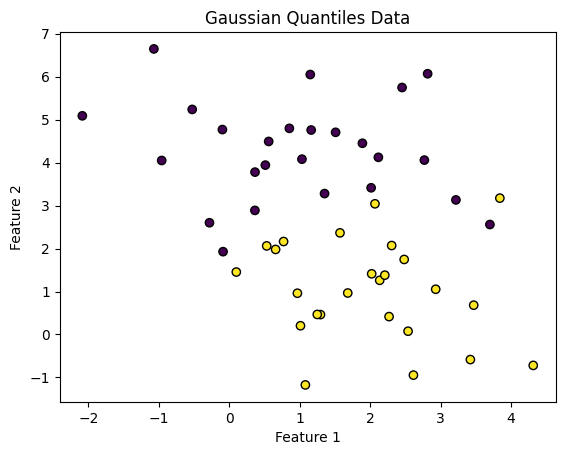

In [53]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, n_features=2, random_state=0, cluster_std=1.2)

# Visualize the Gaussian data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Gaussian Quantiles Data")
plt.show()

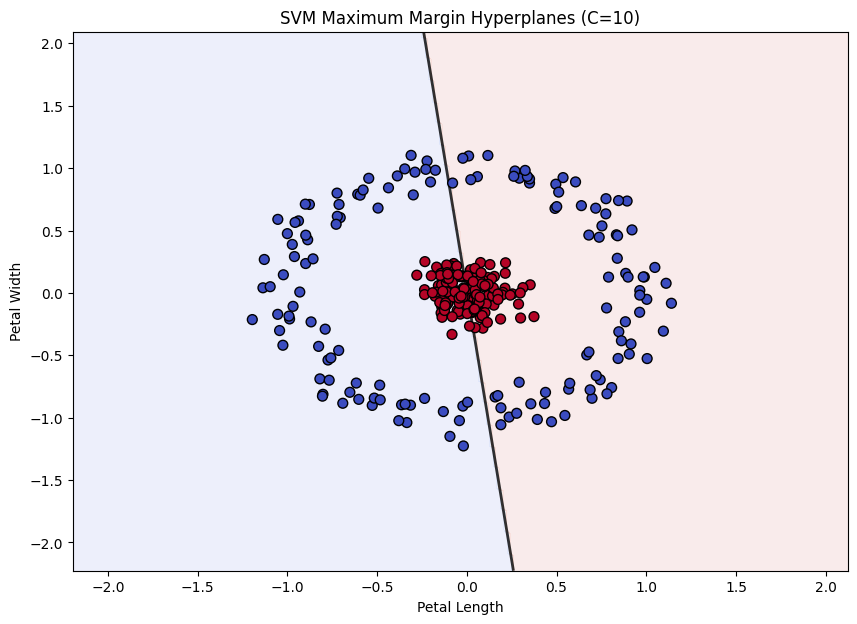

In [90]:
model = LinearSVC(C=10)
model.fit(X, y)
plot_decision_boundary(model, X, y)

## Non-Linear SVM Classification
When data is not linearly separable, SVM can use kernel functions to transform the data into a higher-dimensional space where a linear separation is possible.

In [80]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=300,
    noise=0.1, random_state=42, factor=0.1
)
X.shape, y.shape

((300, 2), (300,))

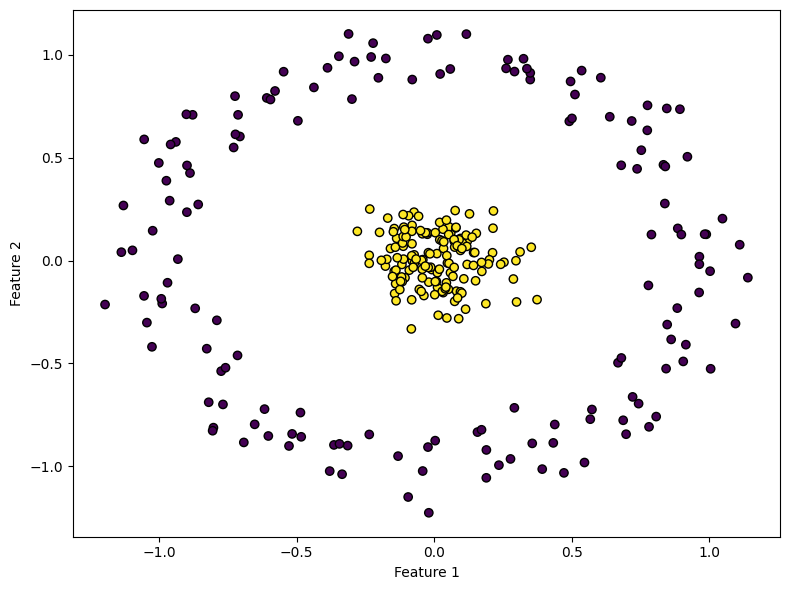

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

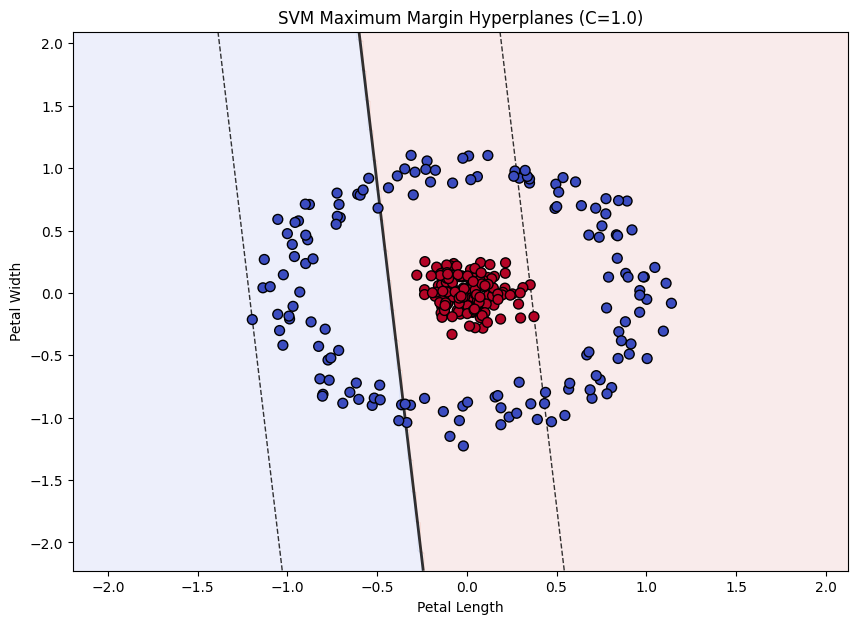

Model Accuracy: 0.68


In [91]:

from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X, y)
plot_decision_boundary(model, X, y)
print(f"Model Accuracy: {model.score(X, y):.2f}")

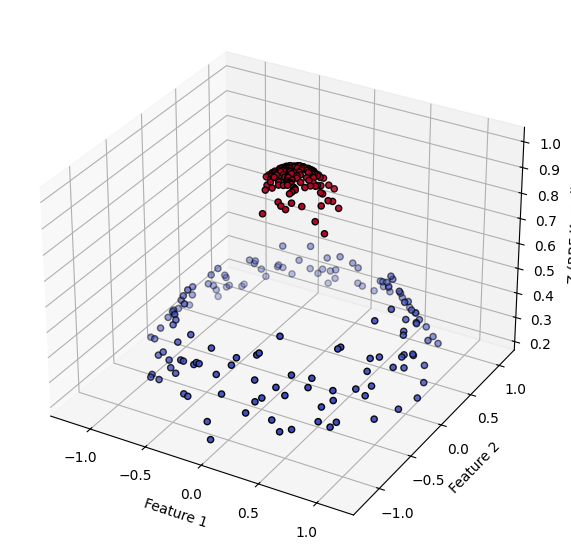

In [86]:
z_values = np.exp(-(X[:, 0]**2 + X[:, 1]**2))

# 3D Scatter Plot with plt.3Dscatter

ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], z_values, c=y, edgecolors='k', cmap='coolwarm')
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Z (RBF Kernel)")
plt.show()


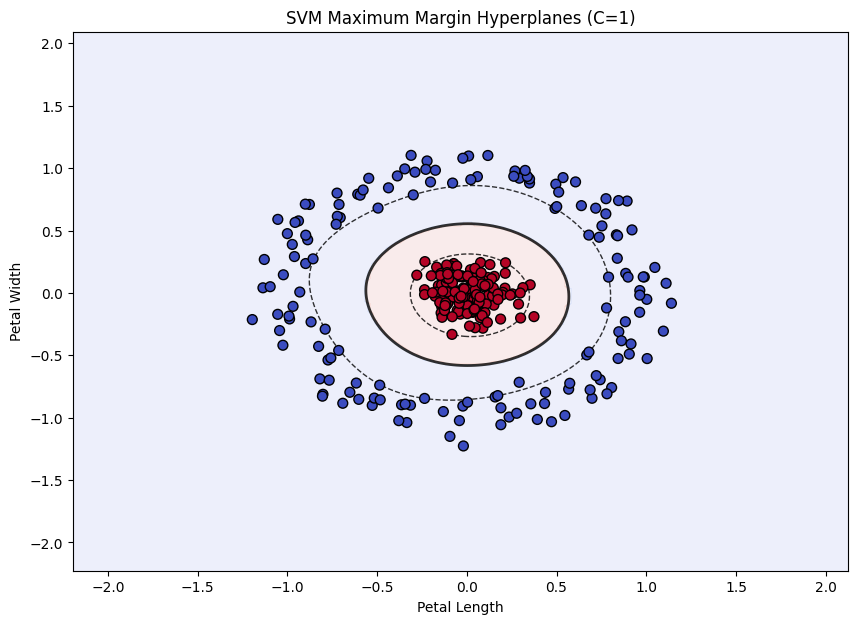

Model Accuracy: 1.00


In [94]:
model = SVC(kernel='rbf', C=1)
model.fit(X, y)
plot_decision_boundary(model, X, y)
print(f"Model Accuracy: {model.score(X, y):.2f}")

In [95]:
model.score(X, y)

1.0

In [96]:
X[0]

array([0.06047829, 0.13344899])

In [97]:
y[0]

np.int64(1)

In [99]:
import numpy as np


X_new = np.array([
    [0.0, 0.0]
])

model.predict(X_new)

array([1])

In [101]:
model.score(X, y)

1.0

## Kernels
A kernel is a function that computes the similarity between two data points in the transformed feature space without explicitly performing the transformation. Common kernels include polynomial and radial basis function (RBF) kernels.

## SVM Regression
SVM can also be used for regression tasks.


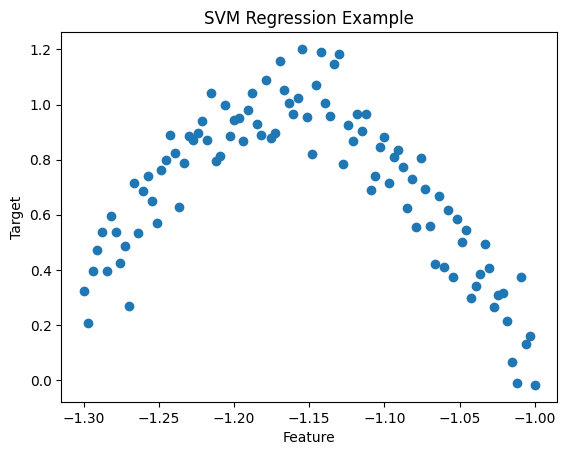

In [102]:
X = np.linspace(-1, -1.3, 100)
y = np.sin(3 * np.pi * X) + np.random.normal(0, 0.1, X.shape)

plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("SVM Regression Example")
plt.show()

In [125]:
from sklearn.svm import SVR

model = SVR(kernel="rbf", C=10, epsilon=0.05)
model.fit(X.reshape(-1, 1), y)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.05
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


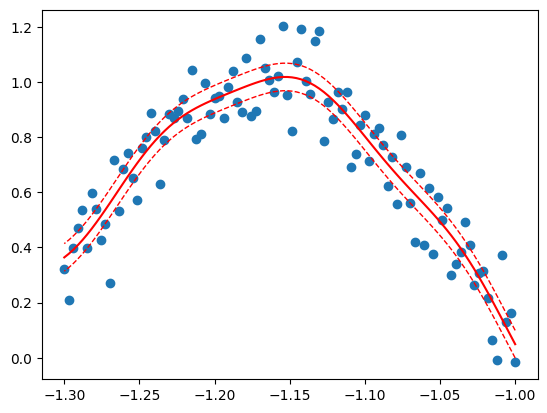

In [126]:
y_pred = model.predict(X.reshape(-1, 1))

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.plot(X, y_pred + model.epsilon, "r--", lw=1, label="Margin (+epsilon)")
plt.plot(X, y_pred - model.epsilon, "r--", lw=1, label="Margin (-epsilon)")
# plt.legend()
plt.show()

In [118]:
model.epsilon

0.1